# Transactions Data Quality Profile — annotated walkthrough
**Dataset:** `transactions.csv` (20,420 rows, 16 columns) — synthetic e-commerce/card transactions.

This version of the notebook explains **every code cell** before you run it: what the code
does line by line, which pandas/numpy/seaborn operation is doing the work, and what result you
should expect to see (so you can tell "this ran correctly" from "something's off"). The actual
numbers you get when you run it should match what's written here, since this exact notebook was
already executed once while building it.

Structure (matches the lab checklist): schema → nulls → duplicates → quantiles → distributions/skew
→ outliers → correlations → PySpark equivalent → eight executable quality rules → write-up answers.

> Run cells **top to bottom** — later cells reuse variables (like `df`, `lower`, `upper`) created
> earlier. Put `transactions.csv` in the same folder as this notebook.


## Setup: imports and loading the data

**What this cell does:**
- `import pandas as pd` — pandas is the library that gives us the `DataFrame`, the table-like
  object everything else in this notebook operates on.
- `import numpy as np` — numpy provides fast numeric arrays and math functions (we use it later
  for z-scores, clipping, etc.). pandas is actually built on top of numpy.
- `import matplotlib.pyplot as plt` — the base plotting library. `seaborn` (next line) is built
  on top of it and makes statistical charts (histograms, boxplots, heatmaps) easier to produce.
- `sns.set_theme(...)` — cosmetic only; gives the charts a consistent, readable style.
- `pd.set_option("display.max_columns", None)` — tells pandas not to truncate the column list
  when it prints a wide DataFrame (we have 16 columns, which would otherwise get collapsed with
  a `...` in the middle).
- `pd.read_csv(DATA_PATH, parse_dates=["transaction_ts"])` — this is the actual data-loading
  step. `read_csv` parses the text file into a DataFrame; `parse_dates=[...]` additionally tells
  pandas to convert the `transaction_ts` column from plain text into a real `datetime64` type
  (without this, it would load as a string, and you couldn't do date arithmetic on it later).

**Expected result:** `df.shape` at the end should print `(20420, 16)` — 20,420 rows, 16 columns.
If you instead get a `FileNotFoundError`, the CSV isn't in the same folder as this notebook (or
`DATA_PATH` needs editing to point at wherever it actually is).

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")     # nicer default look for all charts below
pd.set_option("display.max_columns", None)   # don't truncate wide DataFrames when printed

DATA_PATH = "transactions.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["transaction_ts"])
df.shape   # expect: (20420, 16)


(20420, 16)

## 1. Schema profile

**Why schema first:** before you can judge whether a value is "wrong," you need to know what
*type* pandas thinks each column is, and whether that matches what the column is supposed to
represent (a date that loaded as text, or a flag that loaded as a float, are both schema bugs).

**What `df.info()` does:** for every column, it prints the column name, how many **non-null**
values it has (out of the total row count), and its **dtype** (`int64`, `float64`, `object` for
text/strings, `datetime64[ns]` for dates, etc.). It also prints total memory usage at the bottom.
This single call gives you nulls *and* schema at once — the "Non-Null Count" column is actually
a fast preview of section 2 below.

**Expected result:** 16 rows in the printout (one per column), 20,420 total entries. Columns
`customer_age`, `discount_pct`, `country`, `currency` will show a non-null count **below**
20,420 — that's the null problem we quantify properly in the next section. `transaction_ts`
should show dtype `datetime64[ns]` (because we parsed it as a date on load); everything else
should be `int64` or `float64` except the categorical text columns, which show as `object`.

In [15]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20420 entries, 0 to 20419
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   transaction_id     20420 non-null  int64         
 1   transaction_ts     20420 non-null  datetime64[ns]
 2   customer_id        20420 non-null  int64         
 3   customer_age       19403 non-null  float64       
 4   account_age_days   20420 non-null  int64         
 5   merchant_category  20420 non-null  object        
 6   payment_method     20420 non-null  object        
 7   channel            20420 non-null  object        
 8   country            19968 non-null  object        
 9   currency           19968 non-null  object        
 10  quantity           20420 non-null  int64         
 11  unit_price         20420 non-null  float64       
 12  discount_pct       18991 non-null  float64       
 13  amount             20420 non-null  float64       
 14  num_pr

**What this second cell does:**
- `df.head()` — shows the first 5 rows so you can visually confirm the data looks sane (right
  column names, plausible values, dates that look like dates, etc.). `display()` renders it as a
  nice HTML table in Jupyter instead of the plainer default `print()` formatting.
- The loop over `cat_cols` calls `.nunique(dropna=False)` (count of distinct values, counting
  `NaN` as its own category so it doesn't hide missing data) and `.unique()` (the actual list of
  distinct values) for each categorical column. This tells you the **domain** of each
  categorical — exactly what you need for quality rule #7 later ("is this value even a real
  category?").

**Expected result:** `merchant_category` → 8 unique values (grocery, electronics, travel,
restaurant, clothing, utilities, entertainment, healthcare); `payment_method` → 4; `channel` →
2 (online / in_store); `country` → 8 distinct entries including `nan` (because some rows have a
missing country); `currency` → 4 including `nan`.

In [16]:
display(df.head())

cat_cols = ["merchant_category", "payment_method", "channel", "country", "currency"]
for c in cat_cols:
    print(c, "->", df[c].nunique(dropna=False), "unique values:", df[c].unique())


,transaction_id,transaction_ts,customer_id,customer_age,account_age_days,merchant_category,payment_method,channel,country,currency,quantity,unit_price,discount_pct,amount,num_prior_txns,is_fraud
0,14920,2025-06-26 02:19:45,12634,47.0,691,travel,credit_card,online,MX,MXN,4,459.97,0.219,1438.28,30,0
1,3568,2025-02-11 16:46:57,13878,21.0,539,restaurant,debit_card,in_store,BR,BRL,3,9.46,0.066,26.47,16,0
2,3351,2025-02-12 12:08:39,10117,41.0,2054,electronics,credit_card,in_store,US,USD,2,174.57,0.043,336.19,94,1
3,16021,2025-03-25 05:25:39,13998,47.0,19,grocery,wallet,online,MX,MXN,4,21.19,0.150,69.93,0,0
4,14031,2025-08-11 12:10:20,14956,NaN,179,restaurant,bank_transfer,in_store,BR,BRL,3,6.17,0.148,14.53,11,0


merchant_category -> 8 unique values: ['travel' 'restaurant' 'electronics' 'grocery' 'entertainment' 'utilities'
 'healthcare' 'clothing']
payment_method -> 4 unique values: ['credit_card' 'debit_card' 'wallet' 'bank_transfer']
channel -> 2 unique values: ['online' 'in_store']
country -> 8 unique values: ['MX' 'BR' 'US' 'AR' 'CA' nan 'ES' 'CO']
currency -> 4 unique values: ['MXN' 'BRL' 'USD' nan]


## 2. Null / missing-value profile

**What this cell does:**
- `df.isna()` returns a same-shaped DataFrame of `True`/`False` (`True` where a cell is
  null/`NaN`). `.sum()` on that adds up the `True`s per column (True counts as 1, False as 0),
  giving a **count** of missing values per column.
- `df.isna().mean()` does the same but averages instead of sums, which — since `True`/`False`
  behave as 1/0 — gives the **fraction** missing per column; multiplying by 100 turns it into a
  percentage.
- Both are combined into a small summary DataFrame, sorted descending by percentage missing so
  the worst offenders are at the top, then filtered to `n_missing > 0` so fully-complete columns
  don't clutter the output.

**Why rate, not just count, matters:** 1,017 missing values sounds alarming in isolation, but as
a *rate* (~5%) it's a manageable, disclosable data-quality issue rather than a fatal one — the
percentage is what actually belongs in a report.

**Expected result:** `customer_age` ≈ 1,017 missing (~5.0%), `discount_pct` ≈ 1,429 missing
(~7.0%), `country` and `currency` ≈ 452 each (~2.2%). All other columns should show 0.

In [17]:
null_report = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
}).sort_values("pct_missing", ascending=False)
null_report[null_report.n_missing > 0]


,n_missing,pct_missing
discount_pct,1429,7.00
customer_age,1017,4.98
country,452,2.21
currency,452,2.21


**What this cell does:** `pd.crosstab(A, B)` builds a contingency table — for every combination
of a value in `A` and a value in `B`, it counts how many rows have that combination.
Here `A = df["channel"]` (online / in_store) and `B = df["country"].isna()` (True/False for
whether country is missing). `normalize="index"` converts each row's counts into fractions that
sum to 1 across that row, so instead of raw counts you get *rates* — "of all `online` rows, what
fraction have a missing country?" The `.rename(...)` just relabels the `True` column for
readability.

**Why this matters:** if missingness is spread evenly across the dataset (*missing completely at
random*), you can often just drop or impute those rows without introducing bias. If it's
concentrated in one segment (*missing not at random*) — as it is here — dropping those rows
would silently under-represent that segment, which is worth calling out explicitly rather than
quietly filling/dropping.

**Expected result:** the `online` row should show a noticeably higher missing-country rate than
the `in_store` row (this was deliberately built into the synthetic data) — country/currency were
made to go missing more often specifically for online transactions.

In [18]:
pd.crosstab(df["channel"], df["country"].isna(), normalize="index").rename(columns={True: "country_missing_rate"})


country,False,country_missing_rate
channel,,
in_store,1.000000,0.000000
online,0.959851,0.040149


## 3. Duplicate profile

Two different questions live here, and they need two different checks:
1. **Exact duplicate rows** — every column matches another row exactly. Usually caused by a
   pipeline re-inserting the same record (e.g. a retry after a timeout that actually succeeded).
2. **Duplicate keys with different payloads** — the same `transaction_id` appears more than
   once, but with *different* values elsewhere (e.g. a different `amount`). This is worse: it
   means your "unique identifier" isn't actually unique, and you can no longer trust joins or
   aggregations keyed on it.

**What this cell does:**
- `df.duplicated()` flags every row that is an exact copy of an **earlier** row (the first
  occurrence is `False`, repeats are `True`); `keep=False` instead flags **all** copies including
  the first, which is what you want when you want to *look at* the duplicate groups rather than
  just count them. `.sum()` counts the `True`s.
- `df.duplicated(subset=['transaction_id'])` does the same check but only looking at the
  `transaction_id` column — so it flags any repeated ID regardless of whether the rest of the
  row matches.
- The last line is the more surgical check: `.groupby('transaction_id').filter(lambda g: g['amount'].nunique() > 1)`
  groups rows by id, and **keeps only the groups where `amount` isn't the same across all rows
  in that group** — i.e. it isolates exactly the "same ID, different data" collision case,
  discarding id-groups that are just harmless exact duplicates.

**Expected result:** ~400 exact duplicate rows (~2% of the table); ~420 repeated
`transaction_id` values; the final table should show a handful (~20 rows, in pairs) where the
same id has two different `amount` values — that's the trickier collision case.

In [19]:
full_dupes = df[df.duplicated(keep=False)]
print("Exact duplicate rows:", df.duplicated().sum(), f"({df.duplicated().mean()*100:.2f}% of rows)")

id_dupes = df[df.duplicated(subset=['transaction_id'], keep=False)]
print("transaction_id values that repeat:", df['transaction_id'].duplicated().sum())

# the interesting case: same id, different amount -> real data-integrity problem
id_dupes.sort_values('transaction_id').groupby('transaction_id').filter(lambda g: g['amount'].nunique() > 1).head(10)


Exact duplicate rows: 400 (1.96% of rows)
transaction_id values that repeat: 420


,transaction_id,transaction_ts,customer_id,customer_age,account_age_days,merchant_category,payment_method,channel,country,currency,quantity,unit_price,discount_pct,amount,num_prior_txns,is_fraud
20162,151,2025-08-20 16:33:19,14763,77.0,144,restaurant,credit_card,online,MX,MXN,3,16.24,0.081,46.06,5,0
13846,151,2025-05-28 02:46:21,14785,34.0,280,healthcare,debit_card,online,MX,MXN,3,80.49,0.207,260.04,8,1
8921,2843,2025-07-26 22:17:41,14610,27.0,388,restaurant,credit_card,online,CO,USD,3,10.01,NaN,28.42,15,0
2233,2843,2025-03-09 16:05:39,10318,21.0,49,restaurant,debit_card,online,MX,MXN,3,11.05,0.029,45.87,3,0
13903,3178,2025-09-08 07:12:56,10794,51.0,122,electronics,credit_card,online,MX,MXN,4,82.16,0.031,435.69,4,0
17607,3178,2025-03-22 02:42:13,14321,29.0,59,travel,bank_transfer,in_store,MX,MXN,8,506.73,0.445,2249.96,2,1
14951,4005,2025-08-05 21:22:33,10382,34.0,359,travel,wallet,in_store,US,USD,3,354.00,0.324,718.67,19,0
18569,4005,2025-05-21 02:41:30,13460,51.0,4000,travel,credit_card,in_store,MX,MXN,8,100.41,0.192,890.72,172,0
19423,4100,2025-08-19 20:07:07,10852,53.0,577,grocery,debit_card,online,AR,USD,1,7.10,NaN,3.12,18,0
19008,4100,2025-04-01 16:52:48,14662,35.0,1329,entertainment,debit_card,online,US,USD,3,6.59,0.149,16.22,54,0


## 4. Quantiles / `describe()`

**What `df.describe(include="number")` does:** for every *numeric* column, it computes `count`
(non-null rows), `mean`, `std` (standard deviation), `min`, the `25%`/`50%`/`75%` quantiles
(the 50% quantile is the **median**), and `max` — all in one call. `include="number"` restricts
it to numeric columns only (otherwise it would try to summarize text columns too, which doesn't
make sense for most of these statistics). `.T` transposes the result so columns become rows,
which is just easier to read when you have this many numeric columns.

**Why this is the fastest way to spot a skewed/outlier-prone column:** compare `mean` to `50%`
(the median) for each row. If they're close, the column is roughly symmetric. If `mean` is much
bigger than the median (as you'll see for `amount`), the column is right-skewed — a small number
of very large values are pulling the average upward without moving the "typical" value (the
median) much at all. That single comparison is the seed of the whole median-vs-mean discussion.

**What the second cell adds:** `.quantile([...])` lets you request *specific* percentiles
directly, including ones `describe()` doesn't give you by default (1st, 5th, 95th, 99th) — those
extra tail percentiles are exactly where outliers live, so they matter for section 6.

**Expected result:** for `amount`, `mean` ≈ 259 but the `50%` (median) ≈ 63.5 — roughly a 4x gap,
which is the numeric signature of a right-skewed, outlier-affected column. `min` will be
**negative** (≈ -1,418) — a red flag on its own, since a sale shouldn't have a negative amount;
that's the 26 deliberately-bad rows from section 6/8. `max` will be very large (~125,000) versus
a `75%` of only ~187 — a huge jump in the tail, again pointing at outliers.

In [20]:
df.describe(include="number").T


,count,mean,std,min,25%,50%,75%,max
transaction_id,20420.0,10000.741871,5769.992727,1.00,4997.7500,10006.500,14994.25,20000.00
customer_id,20420.0,12503.701371,1439.504185,10000.00,11262.0000,12500.000,13753.00,14999.00
customer_age,19403.0,41.341597,21.050714,-5.00,32.0000,41.000,50.00,999.00
account_age_days,20420.0,400.090597,400.483627,1.00,118.0000,279.000,553.00,4000.00
quantity,20420.0,3.202106,1.480846,1.00,2.0000,3.000,4.00,11.00
unit_price,20420.0,77.466113,138.951222,1.15,12.2575,25.105,68.83,2077.53
discount_pct,18991.0,0.157950,0.112017,0.00,0.0710,0.134,0.22,0.60
amount,20420.0,258.842052,1536.321078,-1418.43,28.2175,63.535,187.39,125157.49
num_prior_txns,20420.0,16.021009,16.531393,0.00,4.0000,11.000,22.00,172.00
is_fraud,20420.0,0.043879,0.204830,0.00,0.0000,0.000,0.00,1.00


In [21]:
df["amount"].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])


0.01       4.4119
0.05       9.6595
0.25      28.2175
0.50      63.5350
0.75     187.3900
0.95    1002.9475
0.99    2478.8433
Name: amount, dtype: float64

## 5. Distributions & skew

**What the first cell does:**
- `plt.subplots(1, 2, figsize=(12, 4))` creates one figure with two side-by-side chart areas
  (`axes[0]` and `axes[1]`).
- `df["amount"].clip(upper=df["amount"].quantile(0.99))` caps every value above the 99th
  percentile down to that percentile — purely for **plotting readability**: without this, the
  handful of huge outlier values would stretch the x-axis so much that the histogram/boxplot of
  the other 99% of the data would look like a single flat bar. (We are **not** modifying the
  real `df["amount"]` column here — `.clip(...)` returns a new Series; nothing is saved back.)
- `sns.histplot(...)` draws a histogram — it bins the values into ranges and draws a bar per bin
  showing how many rows fall in that range. This is the standard way to *see* a distribution's
  shape (symmetric bell curve vs. a long right/left tail).
- `sns.boxplot(...)` draws a box from the 25th to 75th percentile (the IQR) with a line at the
  median, and "whiskers" extending to roughly 1.5×IQR beyond the box; points plotted beyond the
  whiskers are exactly what a boxplot considers outliers (same rule used numerically in section
  6).
- `df["amount"].skew()` computes the **skewness statistic**: 0 means perfectly symmetric,
  positive means a long right tail (a few unusually large values), negative means a long left
  tail. It's the formal, single-number version of what the histogram shows visually.

**Expected result:** the histogram should show most transactions clustered at low values with a
long thin tail stretching right; the boxplot should show many individual points above the upper
whisker (flagged outliers) even after clipping at the 99th percentile. `skew(amount)` should
print a **large positive number (≈ 50)** — much higher than a "normal" real-world skew of, say,
1–3, because we deliberately injected extreme outliers on top of the naturally skewed base
distribution. The printed mean/median repeats what you saw in section 4 (≈259 vs ≈63.5).

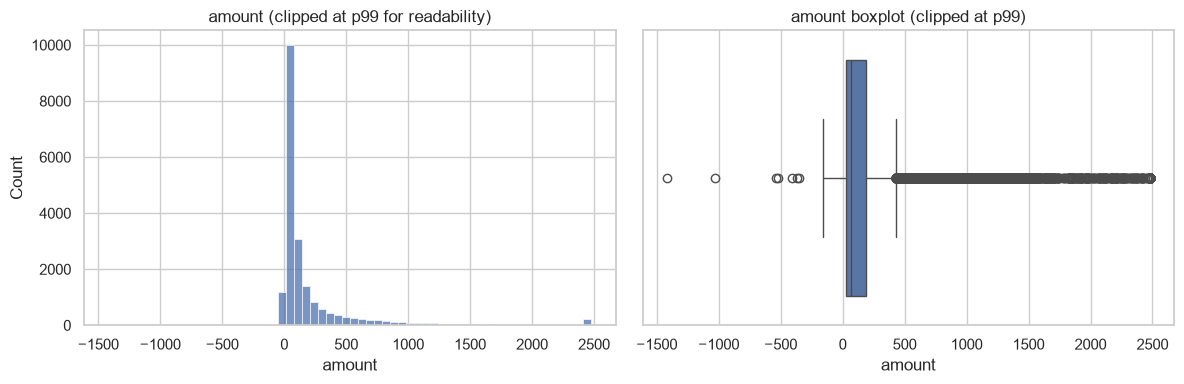

skew(amount): 51.49214460547081
mean vs median: 258.8420519098923 vs 63.535


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["amount"].clip(upper=df["amount"].quantile(0.99)), bins=60, ax=axes[0])
axes[0].set_title("amount (clipped at p99 for readability)")
sns.boxplot(x=df["amount"].clip(upper=df["amount"].quantile(0.99)), ax=axes[1])
axes[1].set_title("amount boxplot (clipped at p99)")
plt.tight_layout()
plt.show()

print("skew(amount):", df["amount"].skew())
print("mean vs median:", df["amount"].mean(), "vs", df["amount"].median())


**What this cell does:** the same `value_counts()` (count of rows per category, used with the
pandas `.plot(kind="bar")` shortcut) and `histplot` idea as above, applied to one categorical
column (`merchant_category`) and one roughly-normal numeric column (`customer_age`) — included so
you have a "well-behaved" distribution to contrast against `amount`'s skew.

**Expected result:** the bar chart shows all 8 merchant categories with broadly similar counts
(grocery and restaurant slightly higher, since they were given higher sampling weight when the
data was generated). The `customer_age` histogram should look like a fairly normal, symmetric
bell curve centered around the high-30s/low-40s — a useful visual contrast to `amount`'s skew:
not every column in the same table is skewed, so you shouldn't apply a blanket "use the median
for everything" rule without checking each column.

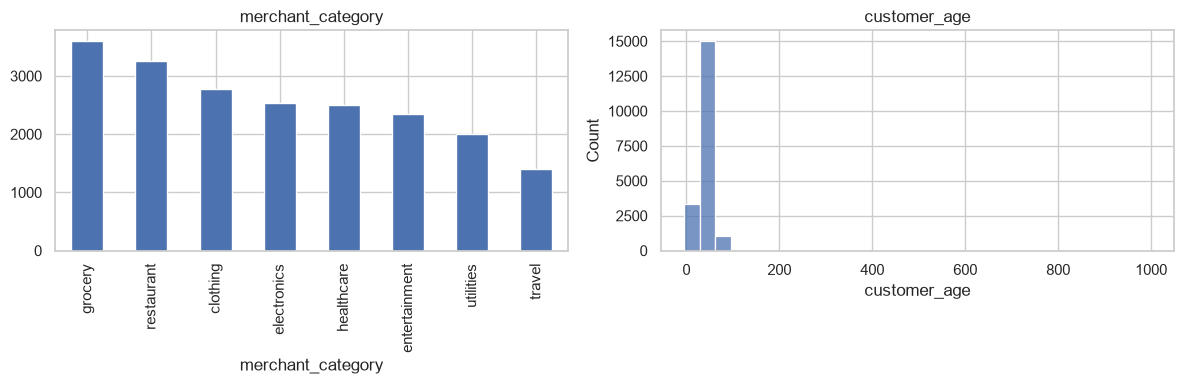

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["merchant_category"].value_counts().plot(kind="bar", ax=axes[0], title="merchant_category")
sns.histplot(df["customer_age"].dropna(), bins=30, ax=axes[1])
axes[1].set_title("customer_age")
plt.tight_layout()
plt.show()


## 6. Outlier detection

**Method 1 — IQR (Tukey) fences.** `q1, q3 = df["amount"].quantile([0.25, 0.75])` pulls the 25th
and 75th percentiles; `iqr = q3 - q1` is the interquartile range (the width of the "middle 50%"
of the data). The classic rule of thumb is that anything more than `1.5 * iqr` below `q1` or
above `q3` counts as an outlier — that's exactly what `lower`/`upper` compute, and the boolean
mask `(df["amount"] < lower) | (df["amount"] > upper)` flags every row outside that range.
`df[mask]` then selects just those rows.

**Method 2 — z-score.** `z = (df["amount"] - mean) / std` converts every value into "how many
standard deviations away from the mean is this?" (a z-score). `z.abs() > 3` is a common cutoff
("more than 3 standard deviations from the mean is unusual"). Note this method uses the
**mean/std**, which are themselves distorted by the very outliers you're trying to detect —
that's a real limitation of the z-score method on skewed data, worth a sentence in your report.

**Why check both:** they don't have to agree, and the gap between them is itself informative — if
IQR flags far more rows than z-score (or vice versa), that tells you something about how extreme
vs. how *frequent* the outliers are.

**The last line** is a much simpler, non-statistical check: `(df['amount'] < 0).sum()` just
counts rows with a negative amount — no threshold or method needed, since a negative sale amount
is definitionally wrong (barring a documented "this is a refund" convention, which this dataset
doesn't have).

**Expected result:** the IQR method should flag roughly **13–14%** of rows (this is high because
`amount`'s underlying distribution is genuinely skewed even before outliers — many *legitimate*
large purchases, like a multi-item travel/electronics order, land past the fence too, which is
worth flagging as a limitation of a naive statistical rule on skewed data). The z-score method
should flag a much smaller fraction (well under 1%), since a handful of extreme million-scale
values dominate the standard deviation and make it very large, so nothing else looks unusual by
comparison. Negative amounts: **26 rows**.

In [24]:
q1, q3 = df["amount"].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
iqr_outliers = df[(df["amount"] < lower) | (df["amount"] > upper)]
print(f"IQR fences: [{lower:.2f}, {upper:.2f}]  ->  {len(iqr_outliers)} outlier rows ({len(iqr_outliers)/len(df)*100:.2f}%)")

z = (df["amount"] - df["amount"].mean()) / df["amount"].std()
z_outliers = df[z.abs() > 3]
print(f"|z| > 3  ->  {len(z_outliers)} outlier rows ({len(z_outliers)/len(df)*100:.2f}%)")

# negative amounts are a different, more obvious problem than "extreme but positive"
print("negative amounts:", (df['amount'] < 0).sum())


IQR fences: [-210.54, 426.15]  ->  2742 outlier rows (13.43%)
|z| > 3  ->  57 outlier rows (0.28%)
negative amounts: 26


## 7. Correlations

**What this cell does:**
- `num_cols` is just the list of numeric columns worth correlating (categorical text columns
  like `merchant_category` are excluded — Pearson correlation, what `.corr()` computes by
  default, only makes sense for numeric data).
- `df[num_cols].corr(numeric_only=True)` computes the **Pearson correlation coefficient**
  between every pair of those columns: a value from -1 (perfect inverse relationship) to +1
  (perfect direct relationship), with 0 meaning no linear relationship. The result is a square
  matrix (row i, column j = correlation between column i and column j; the diagonal is always 1,
  since anything correlates perfectly with itself).
- `clean = df[(df["amount"] > 0) & (df["amount"] < df["amount"].quantile(0.99))]` builds a second
  version of the data with the negative-amount rows and the top 1% (the extreme outliers) removed,
  then recomputes the same correlation matrix on it — so you can see, side by side, how much the
  outliers were distorting the raw correlations.
- `sns.heatmap(...)` visualizes a correlation matrix as a grid of colored cells (red/blue via the
  `"vlag"` colormap, `center=0` so 0 correlation is the neutral midpoint color) with the actual
  numbers annotated on top (`annot=True, fmt=".2f"`).

**Expected result:** in the **raw** heatmap, `amount`'s correlation with `unit_price` and
`quantity` will look surprisingly weak — because a handful of extreme outlier rows add huge
amounts of "noise" variance that swamps the real relationship. In the **cleaned** heatmap (right
panel), `amount` vs `unit_price` should jump to a strong positive correlation (≈0.8), and `amount`
vs `quantity` should show a smaller but real positive correlation (≈0.2) — because `amount` was
*literally constructed* from `quantity * unit_price * (1 - discount_pct)` in this dataset, so this
correlation is genuinely causal by design, not a coincidence. You should also notice `is_fraud`
showing some correlation with other columns (e.g. `num_prior_txns`) — hold onto that for the
causation write-up below, since that one is **not** causal.

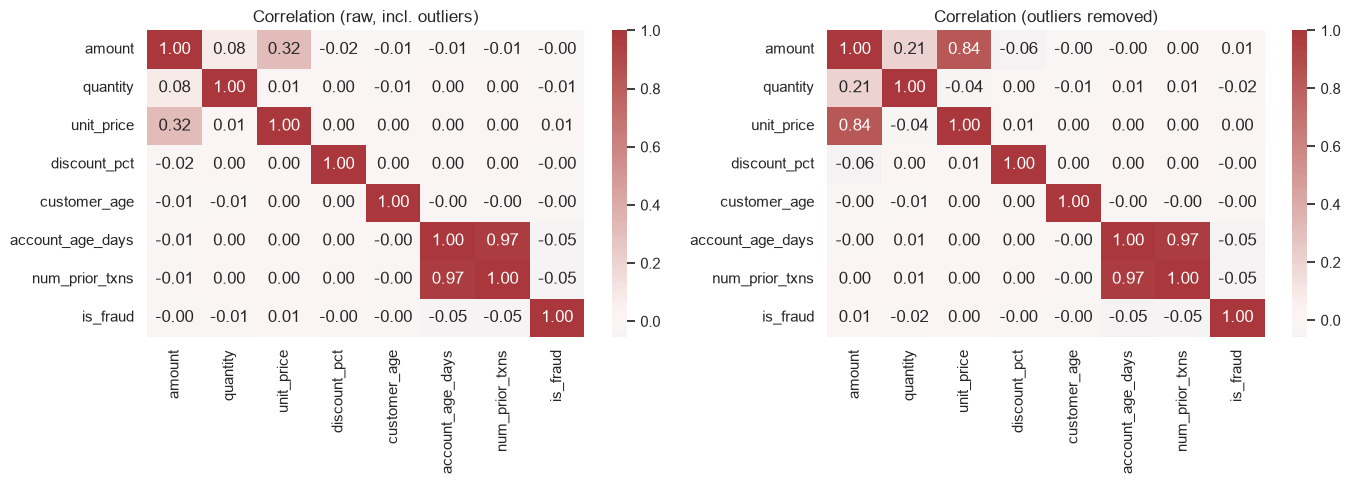

In [25]:
num_cols = ["amount", "quantity", "unit_price", "discount_pct", "customer_age",
            "account_age_days", "num_prior_txns", "is_fraud"]

corr_raw = df[num_cols].corr(numeric_only=True)

clean = df[(df["amount"] > 0) & (df["amount"] < df["amount"].quantile(0.99))]
corr_clean = clean[num_cols].corr(numeric_only=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(corr_raw, annot=True, fmt=".2f", cmap="vlag", center=0, ax=axes[0])
axes[0].set_title("Correlation (raw, incl. outliers)")
sns.heatmap(corr_clean, annot=True, fmt=".2f", cmap="vlag", center=0, ax=axes[1])
axes[1].set_title("Correlation (outliers removed)")
plt.tight_layout()
plt.show()


## 8. PySpark equivalent

This cell is **commented out** on purpose — it needs an actual Spark session (`spark`), which
this notebook doesn't create (that's normally provided for you by the AWS lab environment, e.g.
EMR or Glue). If your lab gives you a Spark/Jupyter kernel with `spark` already available,
uncomment these lines and run them there; the column names match the pandas version above 1:1.

**What each line does, mapped to what you already ran above:**
- `spark.read.csv(..., header=True, inferSchema=True)` — loads the CSV into a Spark DataFrame
  (`sdf`), Spark's distributed equivalent of a pandas DataFrame. `inferSchema=True` asks Spark
  to guess each column's type by scanning the data (slower, but avoids you having to declare
  every column's type by hand).
- `sdf.printSchema()` — Spark's equivalent of `df.info()`'s dtype listing (section 1).
- `sdf.summary()` — Spark's equivalent of `df.describe()` (section 4): count/mean/stddev/min/
  25%/50%/75%/max per column, computed in a distributed way across a cluster instead of in one
  process's memory.
- The `F.count(F.when(F.col(c).isNull(), c))` line — Spark has no single `.isna().sum()`
  shortcut like pandas, so this is the standard pattern: for each column, count how many rows
  have a null in it (this is section 2's null report, Spark-style).
- `sdf.groupBy(sdf.columns).count().filter("count > 1")` — groups by *every* column at once, so
  any group with `count > 1` is, by definition, a set of exact duplicate rows (section 3).
- `sdf.approxQuantile("amount", [...], 0.01)` — Spark's quantiles are *approximate* by default for
  performance on huge datasets; the last argument (`0.01`) is the allowed error tolerance. This
  is section 4's quantile step.
- `sdf.stat.corr("amount", "unit_price")` — a single pairwise Pearson correlation (section 7);
  Spark computes one pair at a time rather than a full matrix in one call.

In [26]:
# --- PySpark version (run this in the lab's Spark/Jupyter kernel) ---
# from pyspark.sql import SparkSession
# from pyspark.sql import functions as F
#
# spark = SparkSession.builder.appName("transactions-profile").getOrCreate()
# sdf = spark.read.csv("transactions.csv", header=True, inferSchema=True)
#
# sdf.printSchema()                                   # schema
# sdf.summary().show()                                 # count/mean/stddev/min/25%/50%/75%/max
# sdf.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in sdf.columns]).show()  # nulls
# sdf.groupBy(sdf.columns).count().filter("count > 1").show()  # duplicate rows
# sdf.approxQuantile("amount", [0.25, 0.5, 0.75, 0.99], 0.01)   # quantiles
# sdf.stat.corr("amount", "unit_price")                          # pairwise correlation


## Eight executable data-quality rules

**Design:** each rule is a small function call — `add_rule(name, description, violation_mask,
max_violation_rate)` — where `violation_mask` is a boolean Series (`True` = this row breaks the
rule), computed the same way as the boolean masks in sections 3/5/6 above. `add_rule` then:
1. Counts how many rows are `True` (`violation_mask.sum()`) — the number of rule-breaking rows.
2. Divides by `len(df)` to get a **rate** rather than a raw count (so the rule's severity is
   comparable across differently-sized datasets).
3. Compares that rate to a chosen `max_violation_rate` **threshold** to decide `PASS`/`FAIL`.
4. Appends all of that as one row (a dict) into the `rules` list, which becomes a summary table
   at the end — that table *is* the "executable" deliverable: it can be re-run on tomorrow's data
   and it will tell you, automatically, whether each rule still holds.

**What each of the 8 rules checks, in plain language:**
1. `pk_unique` — no `transaction_id` should appear more than once (this is what "primary key"
   means).
2. `no_full_duplicates` — no row should be a byte-for-byte copy of another row.
3. `required_not_null` — the columns you can never afford to lose (id, amount, timestamp) must
   never be null.
4. `amount_positive` — a sale amount can't be zero or negative.
5. `amount_within_iqr_fence` — reuses the `lower`/`upper` bounds computed in section 6; allows up
   to 2% of rows to fall outside as a tolerance for the fact that skewed data naturally produces
   some "extreme but legitimate" values.
6. `age_plausible` — a human customer's age should realistically be between 18 and 100 (nulls are
   excluded from this check on purpose — a *missing* age is rule #3's problem, not this one's; a
   present-but-impossible age like 999 is this rule's problem).
7. `category_in_domain` — every `merchant_category` value must be one of the 8 known categories
   (`~df["merchant_category"].isin(valid_categories)` — `.isin` checks membership, `~` negates it
   to flag values that *aren't* in the allowed set).
8. `amount_matches_line_items` — a consistency/referential check: recompute what `amount`
   *should* be from `quantity`, `unit_price`, and `discount_pct`, and flag rows where the actual
   `amount` differs from that expectation by more than a small tolerance (5 units, to allow for
   the small random noise baked into the data).

**Expected result:** rules 3 (`required_not_null`) and 7 (`category_in_domain`) should show
**PASS** (0 violations) — those two data-quality dimensions weren't deliberately broken in this
dataset. The other six should show **FAIL**, each catching one of the specific problems this
notebook profiled above (duplicates, negative amounts, impossible ages, id collisions, and the
inherent skew tripping the IQR fence). A mix of PASS and FAIL is the correct, expected outcome
here — it demonstrates the rules actually catch the issues that are really in the data, rather
than all trivially passing.

In [27]:
rules = []

def add_rule(name, description, violation_mask, max_violation_rate=0.0):
    n = int(violation_mask.sum())
    rate = n / len(df)
    rules.append({
        "rule": name,
        "description": description,
        "violations": n,
        "violation_rate": round(rate, 4),
        "threshold": max_violation_rate,
        "status": "PASS" if rate <= max_violation_rate else "FAIL",
    })

# 1. Primary key uniqueness
add_rule("pk_unique", "transaction_id must be unique",
          df["transaction_id"].duplicated(keep=False), max_violation_rate=0.0)

# 2. No exact duplicate rows
add_rule("no_full_duplicates", "no row may be a byte-for-byte duplicate of another",
          df.duplicated(keep=False), max_violation_rate=0.0)

# 3. Not-null on required fields
add_rule("required_not_null", "customer_id, amount, transaction_ts must never be null",
          df[["customer_id", "amount", "transaction_ts"]].isna().any(axis=1),
          max_violation_rate=0.0)

# 4. Amount must be positive
add_rule("amount_positive", "amount must be > 0 (a real sale, not a refund/error)",
          df["amount"] <= 0, max_violation_rate=0.0)

# 5. Amount within a plausible range (IQR-based, allows a small tail)
add_rule("amount_within_iqr_fence", "amount must fall inside [Q1-1.5*IQR, Q3+1.5*IQR]",
          (df["amount"] < lower) | (df["amount"] > upper), max_violation_rate=0.02)

# 6. customer_age within a plausible human range
add_rule("age_plausible", "customer_age must be between 18 and 100 (nulls excluded)",
          df["customer_age"].notna() & ((df["customer_age"] < 18) | (df["customer_age"] > 100)),
          max_violation_rate=0.0)

# 7. Categorical domain check
valid_categories = {"grocery","electronics","travel","restaurant","clothing",
                     "utilities","entertainment","healthcare"}
add_rule("category_in_domain", "merchant_category must be one of the known categories",
          ~df["merchant_category"].isin(valid_categories), max_violation_rate=0.0)

# 8. Referential/consistency check: amount should roughly equal quantity*unit_price*(1-discount_pct)
expected = df["quantity"] * df["unit_price"] * (1 - df["discount_pct"].fillna(0))
add_rule("amount_matches_line_items", "amount should be within 5 units of quantity*unit_price*(1-discount_pct)",
          (df["amount"] - expected).abs() > 5, max_violation_rate=0.02)

rules_df = pd.DataFrame(rules)
rules_df


,rule,description,violations,violation_rate,threshold,status
0,pk_unique,transaction_id must be unique,840,0.0411,0.00,FAIL
1,no_full_duplicates,no row may be a byte-for-byte duplicate of ano...,800,0.0392,0.00,FAIL
2,required_not_null,"customer_id, amount, transaction_ts must never...",0,0.0000,0.00,PASS
3,amount_positive,"amount must be > 0 (a real sale, not a refund/...",26,0.0013,0.00,FAIL
4,amount_within_iqr_fence,"amount must fall inside [Q1-1.5*IQR, Q3+1.5*IQR]",2742,0.1343,0.02,FAIL
5,age_plausible,customer_age must be between 18 and 100 (nulls...,16,0.0008,0.00,FAIL
6,category_in_domain,merchant_category must be one of the known cat...,0,0.0000,0.00,PASS
7,amount_matches_line_items,amount should be within 5 units of quantity*un...,1185,0.0580,0.02,FAIL


## Write-up: median vs. mean for skewed data
`amount` is right-skewed (skew ≈ 50, driven by a small number of very large transactions and
some data-entry outliers). On this column:

- **mean** ≈ 259, **median** ≈ 64 — the mean is pulled far above where a "typical" transaction
  actually sits, because a handful of extreme values (the outliers plus genuinely large orders)
  dominate the sum.
- The **median** is the 50th percentile: it only cares about *rank*, not *magnitude*, so a $125,000
  outlier moves it no differently than a $200 one would. That makes it a much more robust
  measure of "typical spend" for skewed, outlier-prone data like transaction amounts.
- The mean is still useful — it's what you'd use to reconcile total revenue (mean × count =
  sum), because it *is* sensitive to magnitude. The point isn't "median is always better," it's
  "pick the statistic that matches the question": *typical* transaction → median; *total*
  exposure/revenue → mean (or sum) with the skew flagged in the writeup.

## Write-up: correlation does not imply causation
In the raw correlation heatmap above, `num_prior_txns` and `is_fraud` show a real (negative)
correlation. But in this dataset `is_fraud` was generated from **`account_age_days`** (new
accounts are riskier) and **`channel`**, not from `num_prior_txns` directly — `num_prior_txns`
just happens to be *low* for the same new accounts that are *also* flagged as risky. It's a
shared upstream driver (account age), i.e. a **confounder**, not `num_prior_txns` causing fraud.

General reasons a correlation can show up without one variable causing the other:
1. **Confounding** — a third variable drives both (the case above).
2. **Reverse causation** — B could be causing A instead of A causing B.
3. **Coincidence / small-sample noise** — especially likely with rare events like fraud (only
   ~4.4% positive here).
4. **Data leakage / construction artifacts** — in *this* synthetic dataset, `amount` and
   `unit_price` correlate strongly (~0.84) *because they were built from each other* — that one
   genuinely is causal by construction, which is a useful contrast to point out in the report:
   not every correlation is spurious, but you can't tell which is which from the correlation
   coefficient alone. You need domain knowledge, a controlled comparison, or an experiment to
   claim causation.
